## Proyecto 2: Entrenamiento del Modelo

El dataset utilizado para este proyecto se puede encontrar en el siguiente enlace: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection?select=Dataset

In [32]:
#imports

import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms



In [33]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

In [34]:
#Usar dataset local
model_dir = Path.cwd()
if model_dir.name != "Modelo" and (model_dir / "Modelo").exists():
    model_dir = model_dir / "Modelo"

subset_root = model_dir / "data" / "tomato_subset"

print("Dataset local:", subset_root)
print("Existe:", subset_root.exists())

Dataset local: c:\Users\diego\OneDrive\Documentos\GitHub\Escuela\ICProyecto2\Modelo\data\tomato_subset
Existe: True


In [35]:
#Clases objetivo
TOMATO_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy"
]

CLASS_ALIASES = {
    "Tomato_Spider_mites_Two_spotted_spider_mite": "tomato_spider_mide",
}

def class_alias(class_name):
    return CLASS_ALIASES.get(class_name, class_name)

def graph_label(class_name):
    label = class_alias(class_name)
    changed = True

    while changed:
        changed = False
        for prefix in ("Tomato__", "Tomato_", "tomato_"):
            if label.startswith(prefix):
                label = label[len(prefix):]
                changed = True

    return label

In [36]:
#Validar carpeta local de imagenes
if not subset_root.exists():
    raise FileNotFoundError(f"No se encontro el dataset local: {subset_root}")

missing_classes = [
    class_name for class_name in TOMATO_CLASSES
    if not (subset_root / class_name).exists()
]

if missing_classes:
    raise FileNotFoundError(f"Faltan estas clases en {subset_root}: {missing_classes}")

print("Clases encontradas:", len(TOMATO_CLASSES))

Clases encontradas: 10


In [37]:
#Confirmar subset local de tomates
print("Usando subset local:", subset_root)

for class_name in TOMATO_CLASSES:
    class_dir = subset_root / class_name
    count = sum(
        1 for file_path in class_dir.iterdir()
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )
    print(f"{class_alias(class_name)}: {count} imagenes")

Usando subset local: c:\Users\diego\OneDrive\Documentos\GitHub\Escuela\ICProyecto2\Modelo\data\tomato_subset
Tomato_Bacterial_spot: 2127 imagenes
Tomato_Early_blight: 1000 imagenes
Tomato_Late_blight: 1908 imagenes
Tomato_Leaf_Mold: 952 imagenes
Tomato_Septoria_leaf_spot: 1771 imagenes
tomato_spider_mide: 1676 imagenes
Tomato__Target_Spot: 1404 imagenes
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 imagenes
Tomato__Tomato_mosaic_virus: 373 imagenes
Tomato_healthy: 1591 imagenes


In [38]:
#Conteo
class_counts = {}
total = 0
for class_name in TOMATO_CLASSES:
    class_dir = subset_root / class_name
    count = sum(
        1 for file_path in class_dir.iterdir()
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )
    class_counts[class_alias(class_name)] = count
    total += count
print(class_counts)
print(total)

{'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1908, 'Tomato_Leaf_Mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'tomato_spider_mide': 1676, 'Tomato__Target_Spot': 1404, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 3208, 'Tomato__Tomato_mosaic_virus': 373, 'Tomato_healthy': 1591}
16010


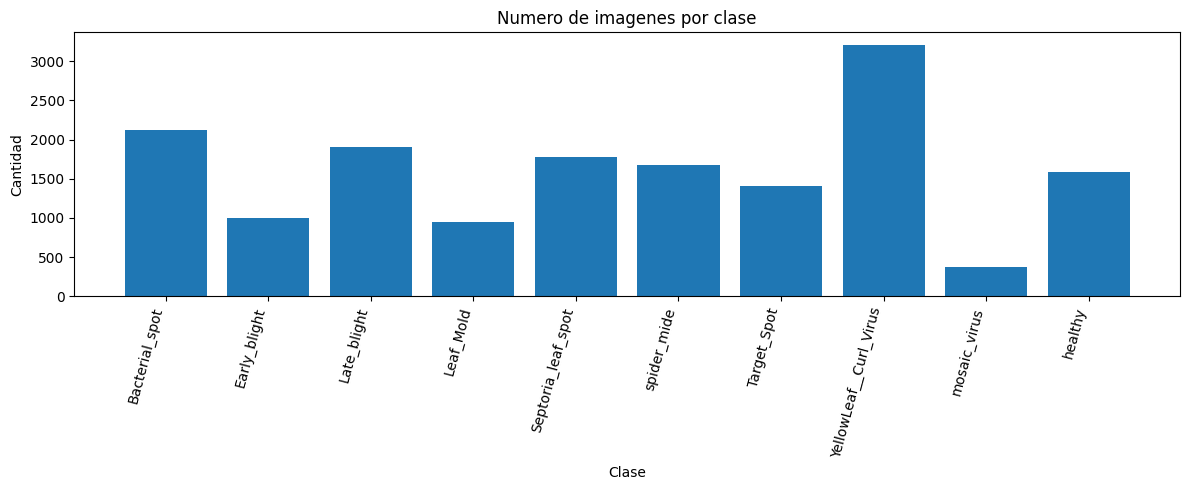

In [39]:
#Distribucion de clases
plt.figure(figsize=(12, 5))
graph_labels = [graph_label(class_name) for class_name in class_counts.keys()]

plt.bar(graph_labels, class_counts.values())
plt.xticks(rotation=75, ha="right")
plt.title("Numero de imagenes por clase")
plt.ylabel("Cantidad")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()